(4, 2)
AND Gate Perceptron Results:
Input: [0 0], Expected Output: 0, Predicted Output: 0
Input: [0 1], Expected Output: 0, Predicted Output: 0
Input: [1 0], Expected Output: 0, Predicted Output: 0
Input: [1 1], Expected Output: 1, Predicted Output: 1


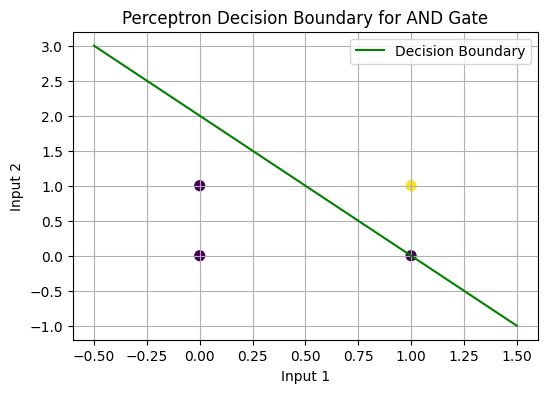

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def step_function(z):
    if z <= 0:
        return 0
    else:
        return 1


def train_perceptron(X, y, epochs=10, learning_rate=0.1):
    num_training_samples, num_features = X.shape
    print(X.shape)
    current_perceptron_weights = np.zeros(num_features)
    current_perceptron_bias = 0

    for current_epoch in range(epochs):
        for sample_index in range(num_training_samples):
            linear_combination = np.dot(X[sample_index], current_perceptron_weights) + current_perceptron_bias
            predicted_value = step_function(linear_combination)
            prediction_error = y[sample_index] - predicted_value

            current_perceptron_weights = current_perceptron_weights + learning_rate * prediction_error * X[sample_index]
            current_perceptron_bias = current_perceptron_bias + learning_rate * prediction_error

    return current_perceptron_weights, current_perceptron_bias

def predict(X, weights, bias):
    linear_combination = np.dot(X, weights) + bias
    predicted_label = step_function(linear_combination)
    return predicted_label


def plot_decision_boundary(X, y, weights, bias, title):
    plt.figure(figsize=(6, 4))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.viridis, s=50)


    plot_x_coords = np.linspace(-0.5, 1.5, 100)

    if weights[1] != 0:
        plot_y_coords = -(weights[0] * plot_x_coords + bias) / weights[1]
        plt.plot(plot_x_coords, plot_y_coords, label='Decision Boundary', color='green')
    else:

        if weights[0] != 0:
            vertical_boundary_line_x = -bias / weights[0]
            plt.axvline(x=vertical_boundary_line_x, color='green', linestyle='--', label='Decision Boundary')
        else:

            print("Weights are all zero, cannot plot a meaningful decision boundary.")


    plt.title(title)
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")

    plt.grid(True)
    plt.legend()
    plt.show()



training_data_X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
target_labels_y = np.array([0, 0, 0, 1])


final_weights, final_bias = train_perceptron(training_data_X, target_labels_y)


print("AND Gate Perceptron Results:")
for sample_index in range(len(training_data_X)):
    current_prediction = predict(training_data_X[sample_index], final_weights, final_bias)
    print(f"Input: {training_data_X[sample_index]}, Expected Output: {target_labels_y[sample_index]}, Predicted Output: {current_prediction}")

plot_decision_boundary(training_data_X, target_labels_y, final_weights, final_bias, "Perceptron Decision Boundary for AND Gate")

In [ ]:
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(2,))
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_split=0.1,
                    verbose=0)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.2f}")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 0.88
